# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [3]:
# Importo las librerías principales que voy a necesitar a lo largo del ejercicio
import pandas as pd                        # Para cargar y manipular datos en formato tabla
import numpy as np                         # Para operaciones matemáticas y transformaciones numéricas
import matplotlib.pyplot as plt            # Para crear gráficos
import seaborn as sns                      # Para gráficos más estilizados (heatmaps, etc.)

from sklearn.preprocessing import StandardScaler   # Para estandarizar (escalar) los datos
from sklearn.decomposition import PCA              # El algoritmo de PCA en sí

import warnings
warnings.filterwarnings('ignore')          # Silencio warnings que no son relevantes

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [4]:
# Cargo el dataset de nutrición
df = pd.read_csv('/Users/andoni/2026-02-BILBAO-FT-Data-Science/3-Machine_Learning/2-No_Supervisado/2-PCA/Practica/data/nndb_flat.csv')

# Miro las primeras filas para ver cómo son los datos
print('Primeras filas del dataset:')
display(df.head())

# Compruebo las dimensiones: cuántas filas y columnas tiene
print(f'\nDimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')

# Veo el tipo de dato de cada columna (object = texto, float64/int64 = numérico)
print('\nTipos de cada columna:')
print(df.dtypes)

# Reviso si hay valores nulos
print('\nValores nulos por columna:')
print(df.isnull().sum())

Primeras filas del dataset:


,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364



Dimensiones del dataset: 8618 filas x 45 columnas

Tipos de cada columna:
ID                    int64
FoodGroup            object
ShortDescrip         object
Descrip              object
CommonName           object
MfgName              object
ScientificName       object
Energy_kcal         float64
Protein_g           float64
Fat_g               float64
Carb_g              float64
Sugar_g             float64
Fiber_g             float64
VitA_mcg            float64
VitB6_mg            float64
VitB12_mcg          float64
VitC_mg             float64
VitE_mg             float64
Folate_mcg          float64
Niacin_mg           float64
Riboflavin_mg       float64
Thiamin_mg          float64
Calcium_mg          float64
Copper_mcg          float64
Iron_mg             float64
Magnesium_mg        float64
Manganese_mg        float64
Phosphorus_mg       float64
Selenium_mcg        float64
Zinc_mg             float64
VitA_USRDA          float64
VitB6_USRDA         float64
VitB12_USRDA        float64
V

### Mira la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

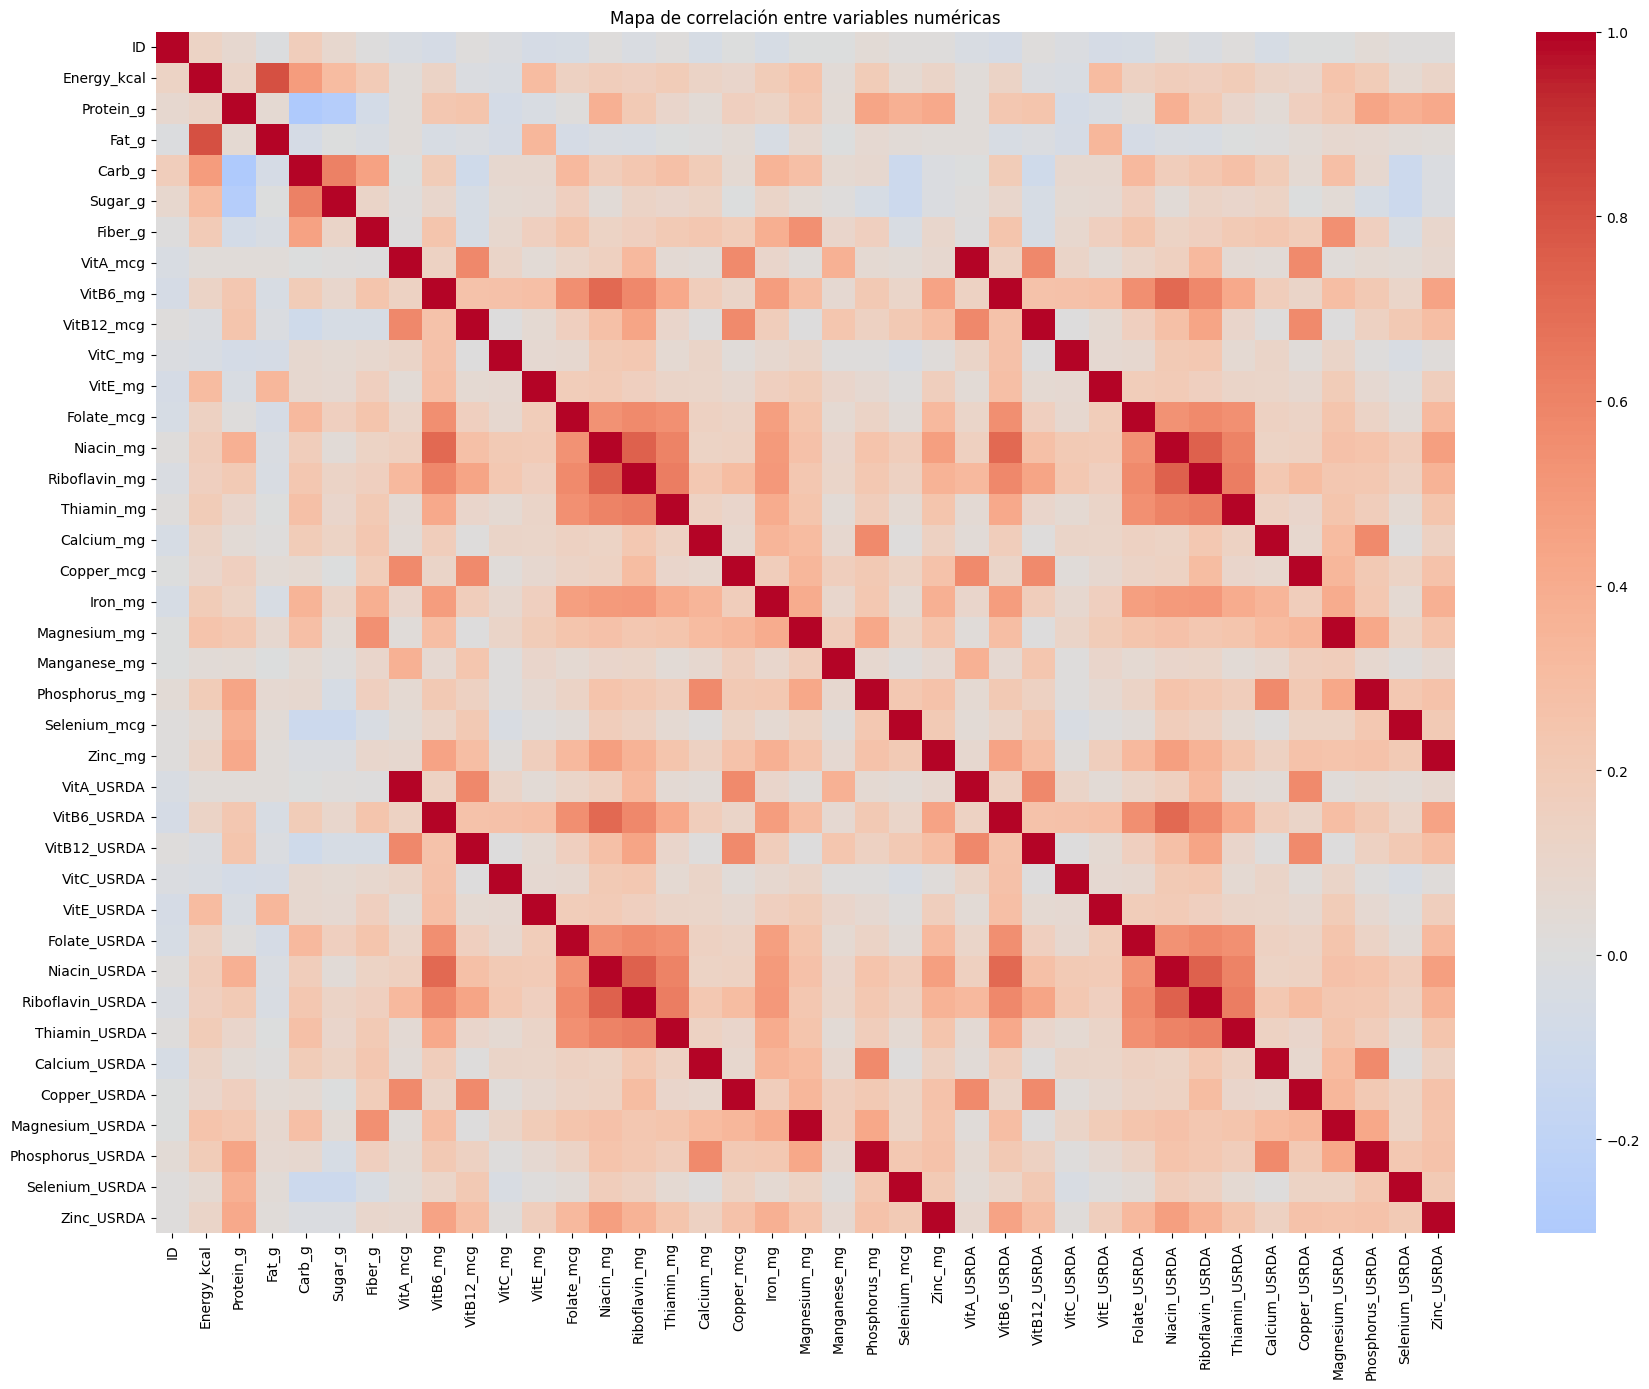

Columnas USRDA encontradas (redundantes con su nutriente base, las eliminaré):
['VitA_USRDA', 'VitB6_USRDA', 'VitB12_USRDA', 'VitC_USRDA', 'VitE_USRDA', 'Folate_USRDA', 'Niacin_USRDA', 'Riboflavin_USRDA', 'Thiamin_USRDA', 'Calcium_USRDA', 'Copper_USRDA', 'Magnesium_USRDA', 'Phosphorus_USRDA', 'Selenium_USRDA', 'Zinc_USRDA']


In [5]:
# Selecciono sólo las columnas numéricas para calcular la correlación
df_numeric = df.select_dtypes(include=[np.number])

# Calculo la matriz de correlación: mide cuánto se relacionan linealmente dos variables
# Valores cerca de 1 o -1 = alta correlación; cerca de 0 = poca relación
corr_matrix = df_numeric.corr()

# Represento la correlación como un mapa de calor para verla de forma visual
plt.figure(figsize=(18, 14))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Mapa de correlación entre variables numéricas')
plt.tight_layout()
plt.show()

# Identifico las columnas USRDA (United States Recommended Daily Allowance)
# Estas columnas suelen ser proporcionales a las variables originales (son el % del valor diario recomendado)
# por lo que están altamente correlacionadas con su nutriente base -> son redundantes
usrda_cols = [col for col in df_numeric.columns if 'USRDA' in col]
print('Columnas USRDA encontradas (redundantes con su nutriente base, las eliminaré):')
print(usrda_cols)

**Conclusión:** Las columnas USRDA son simplemente el porcentaje del valor diario recomendado de cada nutriente. Esto significa que están perfectamente correlacionadas (o casi) con las columnas de nutrientes originales — aportan información duplicada. Las elimino para no distorsionar el PCA.

### Variables no numéricas
Elimina las variables de texto del dataset

In [6]:
# Guardo las columnas de texto por si las necesito más adelante (por ejemplo, FoodGroup)
df_text = df.select_dtypes(include=['object'])
print('Columnas de texto que voy a guardar aparte:')
print(df_text.columns.tolist())

# Guardo la columna FoodGroup específicamente para usarla al final del ejercicio
food_group = df['FoodGroup'].copy()

# Me quedo sólo con las columnas numéricas, eliminando también las columnas USRDA redundantes
df_clean = df.select_dtypes(include=[np.number])
df_clean = df_clean.drop(columns=usrda_cols, errors='ignore')

print(f'\nDimensiones tras eliminar columnas de texto y USRDA: {df_clean.shape}')
print('Columnas que me quedan:')
print(df_clean.columns.tolist())

Columnas de texto que voy a guardar aparte:
['FoodGroup', 'ShortDescrip', 'Descrip', 'CommonName', 'MfgName', 'ScientificName']

Dimensiones tras eliminar columnas de texto y USRDA: (8618, 24)
Columnas que me quedan:
['ID', 'Energy_kcal', 'Protein_g', 'Fat_g', 'Carb_g', 'Sugar_g', 'Fiber_g', 'VitA_mcg', 'VitB6_mg', 'VitB12_mcg', 'VitC_mg', 'VitE_mg', 'Folate_mcg', 'Niacin_mg', 'Riboflavin_mg', 'Thiamin_mg', 'Calcium_mg', 'Copper_mcg', 'Iron_mg', 'Magnesium_mg', 'Manganese_mg', 'Phosphorus_mg', 'Selenium_mcg', 'Zinc_mg']


### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

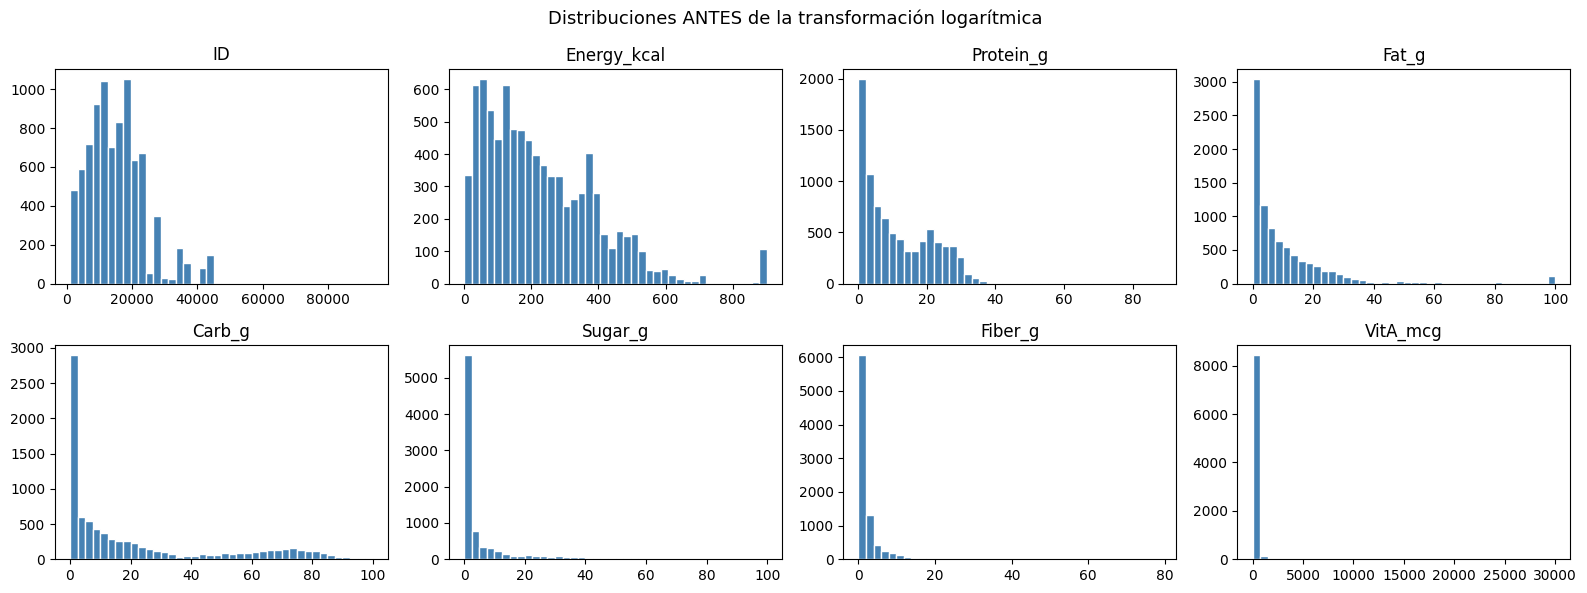

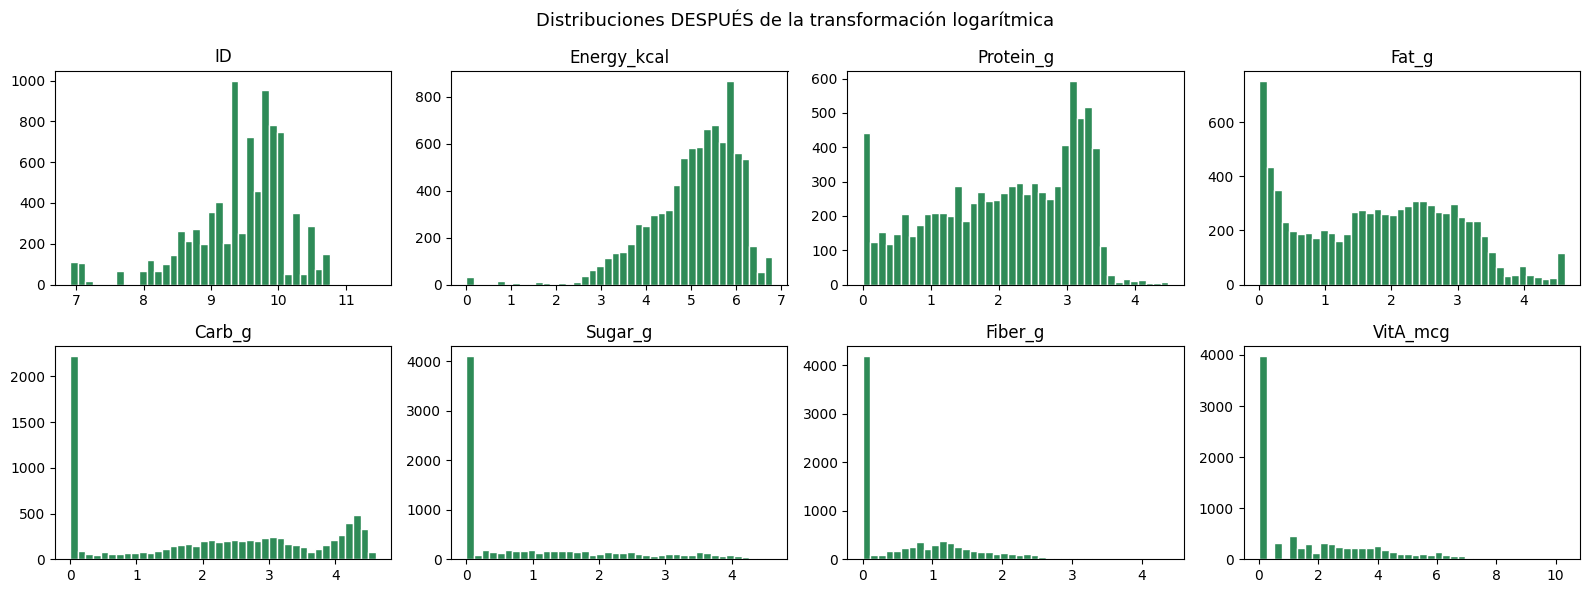

Transformación logarítmica aplicada correctamente.


In [7]:
# Visualizo la distribución de algunas variables ANTES de transformar
# Esto me ayuda a ver la asimetría ("cola" larga a la derecha)
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, col in enumerate(df_clean.columns[:8]):
    axes[i//4, i%4].hist(df_clean[col].dropna(), bins=40, color='steelblue', edgecolor='white')
    axes[i//4, i%4].set_title(col)
plt.suptitle('Distribuciones ANTES de la transformación logarítmica', fontsize=13)
plt.tight_layout()
plt.show()

# Aplicar transformación logarítmica: log(x+1) para evitar log(0) que es infinito
# Esta transformación "aplana" distribuciones con cola larga y las acerca a una normal
df_log = np.log1p(df_clean.clip(lower=0))  # clip(lower=0) para asegurar que no hay negativos

# Visualizo las distribuciones DESPUÉS de transformar
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, col in enumerate(df_log.columns[:8]):
    axes[i//4, i%4].hist(df_log[col].dropna(), bins=40, color='seagreen', edgecolor='white')
    axes[i//4, i%4].set_title(col)
plt.suptitle('Distribuciones DESPUÉS de la transformación logarítmica', fontsize=13)
plt.tight_layout()
plt.show()

print('Transformación logarítmica aplicada correctamente.')

**¿Por qué transformación logarítmica?** Muchos nutrientes tienen distribuciones muy sesgadas: la mayoría de alimentos tienen poco de algo, pero unos pocos tienen cantidades enormes (ej: proteínas en carnes vs. verduras). El logaritmo comprime esos valores extremos y hace que la distribución se parezca más a una campana de Gauss (normal), lo que mejora la eficacia del PCA.

### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [8]:
# Estandarizo los datos con StandardScaler
# Esto transforma cada variable para que tenga media=0 y desviación típica=1
# Es IMPRESCINDIBLE antes del PCA porque si una variable tiene valores en miles
# y otra en decimales, la primera dominaría artificialmente el análisis

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_log)

# Convierto de array numpy a DataFrame para que sea más manejable
df_scaled = pd.DataFrame(df_scaled, columns=df_log.columns)

print('Datos estandarizados correctamente.')
print(f'Media de cada columna (debe ser ~0):')
print(df_scaled.mean().round(5))
print(f'\nDesviación típica de cada columna (debe ser ~1):')
print(df_scaled.std().round(5))

Datos estandarizados correctamente.
Media de cada columna (debe ser ~0):
ID               0.0
Energy_kcal     -0.0
Protein_g        0.0
Fat_g            0.0
Carb_g           0.0
Sugar_g         -0.0
Fiber_g          0.0
VitA_mcg         0.0
VitB6_mg         0.0
VitB12_mcg       0.0
VitC_mg         -0.0
VitE_mg         -0.0
Folate_mcg      -0.0
Niacin_mg       -0.0
Riboflavin_mg   -0.0
Thiamin_mg       0.0
Calcium_mg      -0.0
Copper_mcg      -0.0
Iron_mg         -0.0
Magnesium_mg    -0.0
Manganese_mg     0.0
Phosphorus_mg   -0.0
Selenium_mcg     0.0
Zinc_mg         -0.0
dtype: float64

Desviación típica de cada columna (debe ser ~1):
ID               1.00006
Energy_kcal      1.00006
Protein_g        1.00006
Fat_g            1.00006
Carb_g           1.00006
Sugar_g          1.00006
Fiber_g          1.00006
VitA_mcg         1.00006
VitB6_mg         1.00006
VitB12_mcg       1.00006
VitC_mg          1.00006
VitE_mg          1.00006
Folate_mcg       1.00006
Niacin_mg        1.00006
Riboflav

### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [9]:
# Obtengo el número total de variables (= número máximo de componentes posibles)
n_features = df_scaled.shape[1]
print(f'Número de variables originales: {n_features}')

# Creo y entreno el PCA con TODOS los componentes posibles
# PCA encuentra nuevas dimensiones (combinaciones de las originales) ordenadas
# de mayor a menor varianza explicada
pca_full = PCA(n_components=n_features)
pca_full.fit(df_scaled)

print('\nPCA entrenado correctamente con todos los componentes.')
print(f'Número de componentes generados: {pca_full.n_components_}')

Número de variables originales: 24

PCA entrenado correctamente con todos los componentes.
Número de componentes generados: 24


### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

Con 7 componentes principales explico el 75.3% de la varianza original.


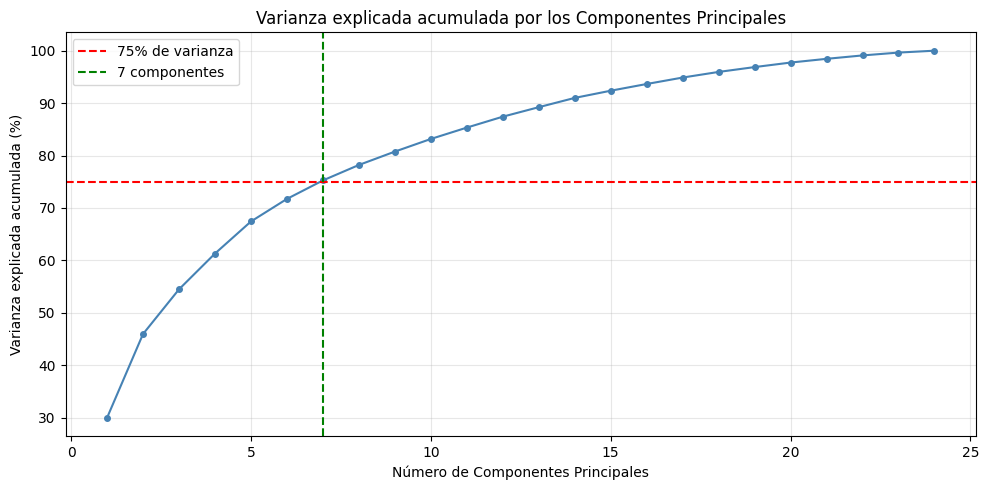


Decisión: me quedo con 7 componentes principales.


In [10]:
# explained_variance_ratio_ es un array con el % de varianza que explica cada componente
varianza_por_pc = pca_full.explained_variance_ratio_

# Calculo la varianza acumulada: voy sumando componente a componente
varianza_acumulada = np.cumsum(varianza_por_pc)

# Busco cuántos PCs necesito para alcanzar el umbral del 70-75%
umbral = 0.75
n_pcs_necesarios = np.argmax(varianza_acumulada >= umbral) + 1  # +1 porque el índice empieza en 0
print(f'Con {n_pcs_necesarios} componentes principales explico el {varianza_acumulada[n_pcs_necesarios-1]*100:.1f}% de la varianza original.')

# Gráfico de la varianza acumulada
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada * 100, marker='o', markersize=4, color='steelblue')
plt.axhline(y=75, color='red', linestyle='--', label='75% de varianza')
plt.axvline(x=n_pcs_necesarios, color='green', linestyle='--', label=f'{n_pcs_necesarios} componentes')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza explicada acumulada (%)')
plt.title('Varianza explicada acumulada por los Componentes Principales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nDecisión: me quedo con {n_pcs_necesarios} componentes principales.')

## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [11]:
# Creo un nuevo PCA con sólo los componentes seleccionados (reducción de dimensionalidad)
# Esto me permite pasar de N variables originales a solo n_pcs_necesarios, perdiendo poco
pca_reducido = PCA(n_components=n_pcs_necesarios)

# fit_transform: entrena el PCA Y proyecta los datos en el nuevo espacio reducido
X_reducido = pca_reducido.fit_transform(df_scaled)

# Convierto a DataFrame con nombres descriptivos para los componentes
nombres_pcs = [f'PC{i+1}' for i in range(n_pcs_necesarios)]
df_pca = pd.DataFrame(X_reducido, columns=nombres_pcs)

print(f'Dataset original: {df_scaled.shape[1]} variables')
print(f'Dataset reducido con PCA: {df_pca.shape[1]} componentes')
print(f'Número de registros: {df_pca.shape[0]} (igual que el original)')
print('\nPrimeras filas del dataset reducido:')
display(df_pca.head())

Dataset original: 24 variables
Dataset reducido con PCA: 7 componentes
Número de registros: 8618 (igual que el original)

Primeras filas del dataset reducido:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-2.254172,-0.864286,-0.068343,0.725155,5.309627,0.278329,-1.943614
1,-2.221566,-0.805947,-0.048057,0.716533,5.282442,0.318619,-1.971784
2,-3.381271,-1.038799,0.474542,1.650204,5.350524,1.293928,-2.081512
3,1.409058,-1.152702,-1.430842,-0.616309,3.647042,-2.149937,-2.209234
4,1.123787,-1.093036,-1.326571,-0.858790,3.929694,-2.392220,-2.149718


### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.

In [12]:
# Añado la columna FoodGroup al DataFrame de componentes para poder agrupar
df_pca['FoodGroup'] = food_group.values

print('Top 3 grupos de comida con mayor valor medio en cada Componente Principal:')
print('=' * 60)

for pc in nombres_pcs:
    # Calculo la media del PC para cada grupo de comida
    media_por_grupo = df_pca.groupby('FoodGroup')[pc].mean()
    
    # Ordeno de mayor a menor y me quedo con los 3 primeros
    top3 = media_por_grupo.nlargest(3)
    
    print(f'\n{pc}:')
    for grupo, valor in top3.items():
        print(f'   {grupo:<40} → media = {valor:.4f}')

Top 3 grupos de comida con mayor valor medio en cada Componente Principal:

PC1:
   Breakfast Cereals                        → media = 4.0012
   Nut and Seed Products                    → media = 3.1183
   Spices and Herbs                         → media = 2.4767

PC2:
   Spices and Herbs                         → media = 3.7225
   Breakfast Cereals                        → media = 2.7665
   Nut and Seed Products                    → media = 2.2676

PC3:
   Baked Products                           → media = 1.9041
   Fats and Oils                            → media = 1.6453
   Sweets                                   → media = 1.3575

PC4:
   Breakfast Cereals                        → media = 2.2286
   Fats and Oils                            → media = 1.3264
   Baby Foods                               → media = 0.5654

PC5:
   Fats and Oils                            → media = 3.1444
   Dairy and Egg Products                   → media = 2.4475
   Baby Foods                            